## Exploratory Data Analysis (EDA)

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, recall_score, roc_auc_score
from imblearn.combine import SMOTETomek
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [135]:
df=pd.read_csv('hr_employee_churn_data.csv')

In [136]:
df.head()

,empid,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
0,1,0.38,0.53,2,157,3,0,0,low,1
1,2,0.80,0.86,5,262,6,0,0,medium,1
2,3,0.11,0.88,7,272,4,0,0,medium,1
3,4,0.72,0.87,5,223,5,0,0,low,1
4,5,0.37,0.52,2,159,3,0,0,low,1


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   empid                  14999 non-null  int64  
 1   satisfaction_level     14997 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_monthly_hours  14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   salary                 14999 non-null  str    
 9   left                   14999 non-null  int64  
dtypes: float64(2), int64(7), str(1)
memory usage: 1.2 MB


In [138]:
df.shape

(14999, 10)

In [139]:
df.isna().sum()

empid                    0
satisfaction_level       2
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
salary                   0
left                     0
dtype: int64

In [140]:
df.describe()

,empid,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,left
count,14999.000000,14997.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7500.000000,0.612863,0.716102,3.803054,201.050337,3.498233,0.144610,0.021268,0.238083
std,4329.982679,0.248634,0.171169,1.232592,49.943099,1.460136,0.351719,0.144281,0.425924
min,1.000000,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,3750.500000,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,7500.000000,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,11249.500000,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,14999.000000,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [141]:
df['Work_accident'].unique()

array([0, 1])

In [142]:
df['promotion_last_5years'].unique()

array([0, 1])

In [ ]:
#split dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
df_merge_train = pd.concat([X_train, y_train],axis=1)
df_merge_train.head()

,empid,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
6026,6027,0.49,0.46,2,129,2,0,0,high,0
11511,11512,0.72,0.88,5,216,10,1,0,medium,0
13663,13664,0.82,0.51,2,268,2,0,0,high,0
11239,11240,0.82,0.85,3,214,2,0,0,high,0
676,677,0.11,0.82,6,270,4,0,0,low,1


In [180]:
df_merge_test = pd.concat([X_test, y_test],axis=1)
df_merge_test.head()

,empid,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
7241,7242,0.96,0.93,6,240,6,0,0,low,0
6289,6290,0.61,0.69,3,224,3,0,0,medium,0
9018,9019,0.94,0.61,4,199,3,0,0,low,0
14412,14413,0.39,0.50,2,135,3,0,0,low,1
9098,9099,0.96,0.52,4,228,3,0,0,low,0


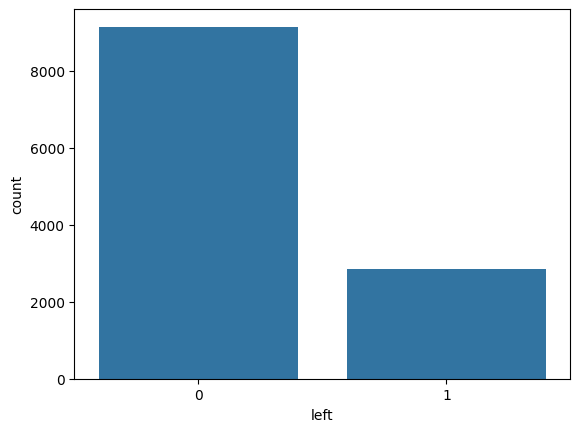

In [162]:
# check total employee range based on target column that left
sns.countplot(x='left',data=df_merge_train)
plt.show()
#Take-away: in the training set, less people left than didn't.it seems there is data imbalance..

<Axes: xlabel='salary', ylabel='count'>

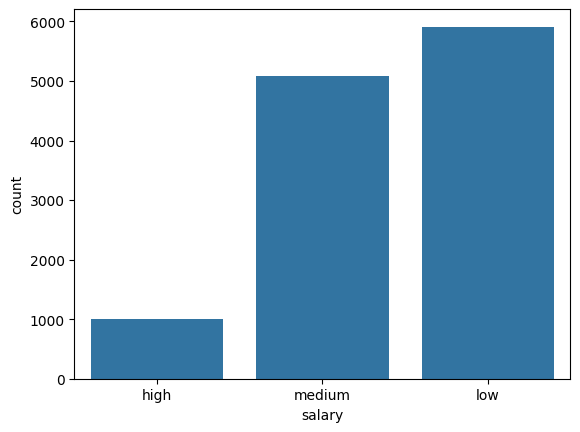

In [163]:
#feature 'salary'
sns.countplot(x='salary', data=df_merge_train)
#take-away: low salaried employee count is high in given dataset as expected

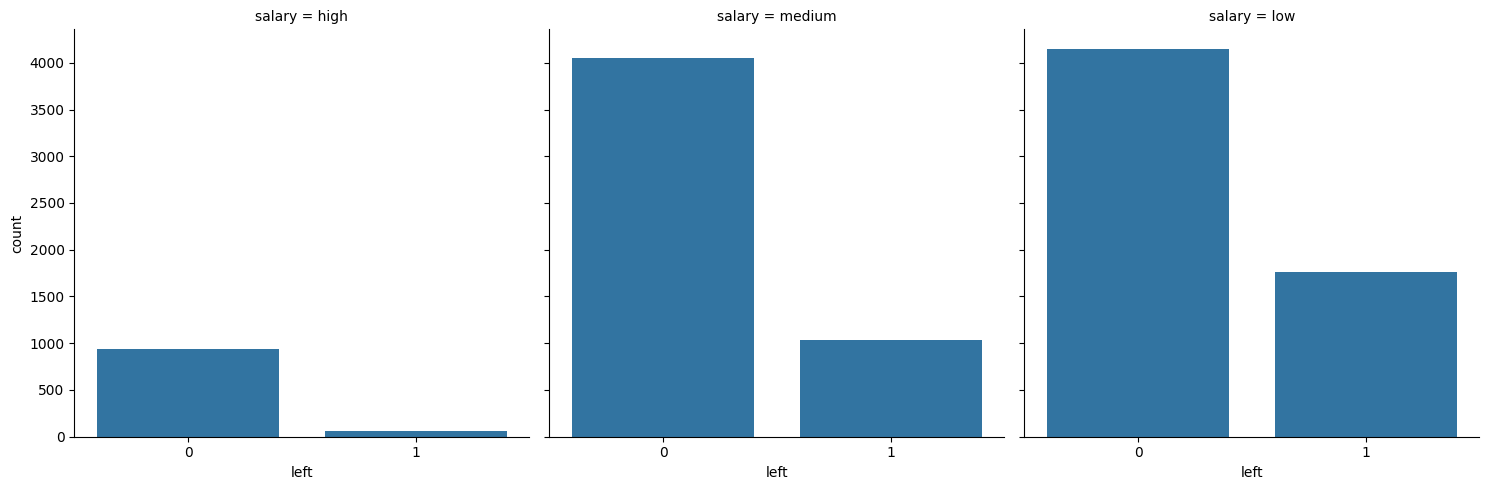

In [164]:
#feature 'left' split over the feature 'salary'.
sns.catplot(x='left', col='salary', kind='count', data=df_merge_train)
#Take-away: it seem low salaried employees have high churning rate

<Axes: xlabel='promotion_last_5years', ylabel='count'>

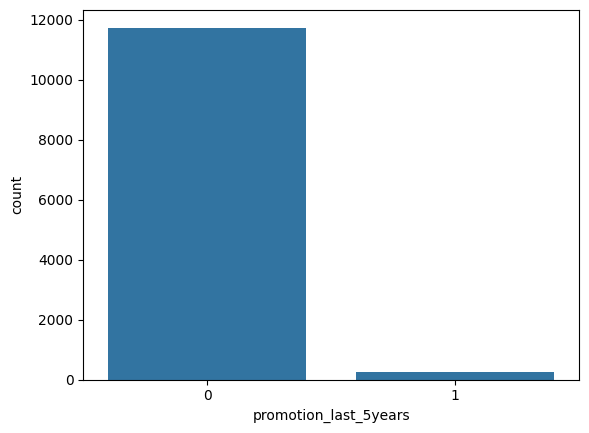

In [165]:
#feature 'promotion_last_5years'
sns.countplot(x='promotion_last_5years', data=df_merge_train)
#take-away: non promoted emp count is high

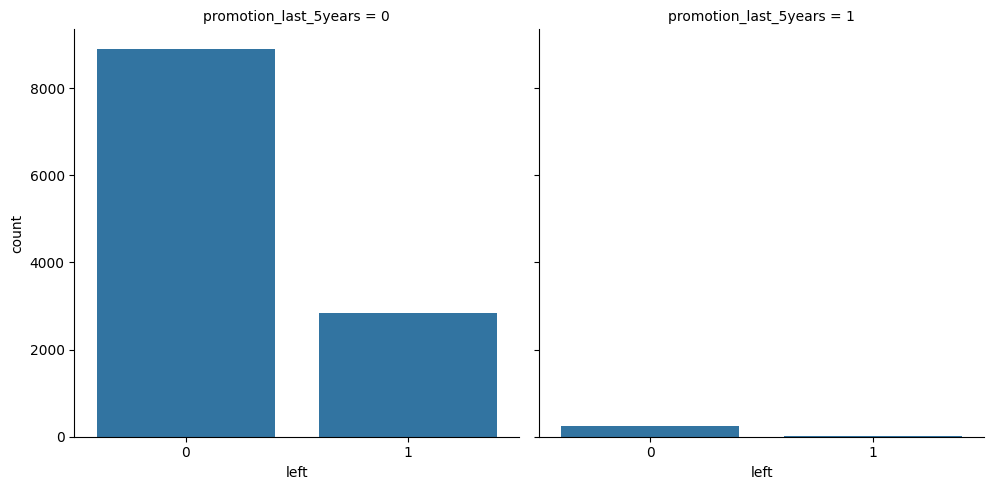

In [166]:
#feature 'left' split over the feature 'promotion_last_5years'.
#fig = plt.figure(figsize=(15,7))
sns.catplot(x='left', col='promotion_last_5years', kind='count', data=df_merge_train)
#Take-away: it seems non promoted people left more

<Axes: xlabel='Work_accident', ylabel='count'>

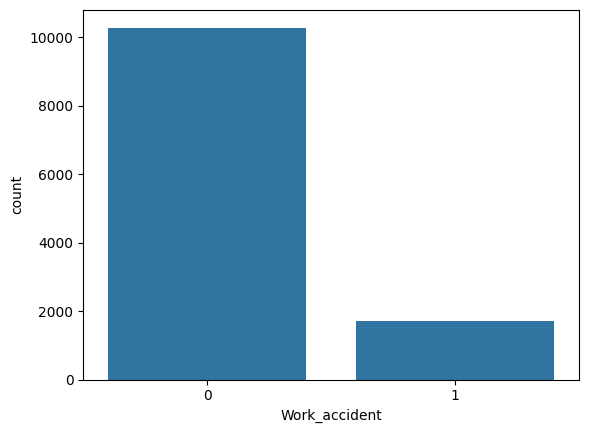

In [167]:
#feature 'Work_accident'
sns.countplot(x='Work_accident', data=df_merge_train)
#take-away: have less people who made Work_accident

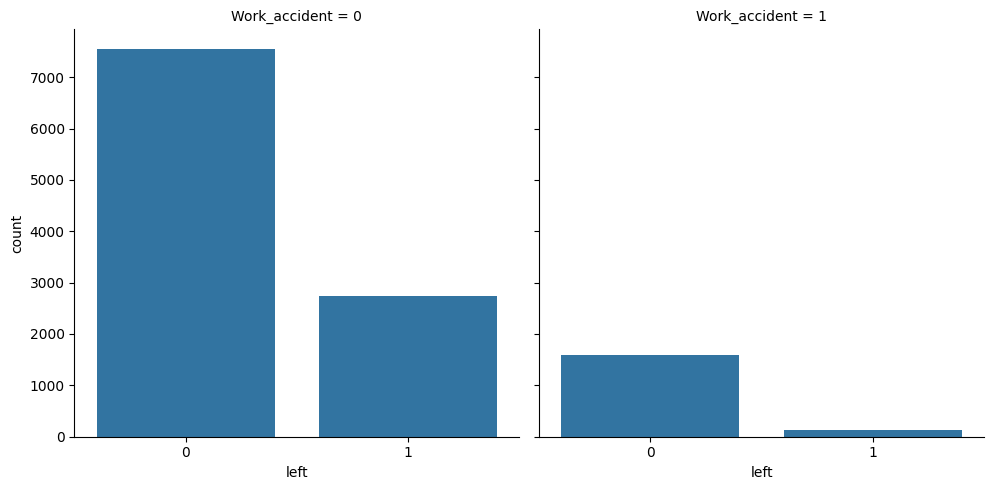

In [168]:
#feature 'left' split over the feature 'Work_accident'.
#fig = plt.figure(figsize=(15,7))
sns.catplot(x='left', col='Work_accident', kind='count', data=df_merge_train)
#Take-away: it seems people left more who did not made accident...we can say it is less imp feature 

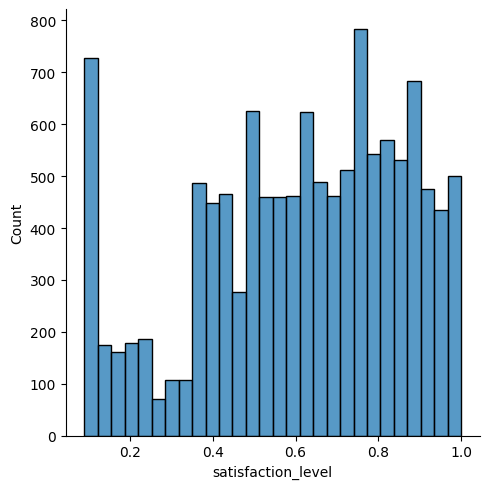

In [169]:
# satisfaction_level : plot a univariate distribution of observations
sns.displot(df_merge_train['satisfaction_level'])
#take-away: sl distributed from 0.1 to 1 where it has high count at 0.1

<Axes: xlabel='left', ylabel='satisfaction_level'>

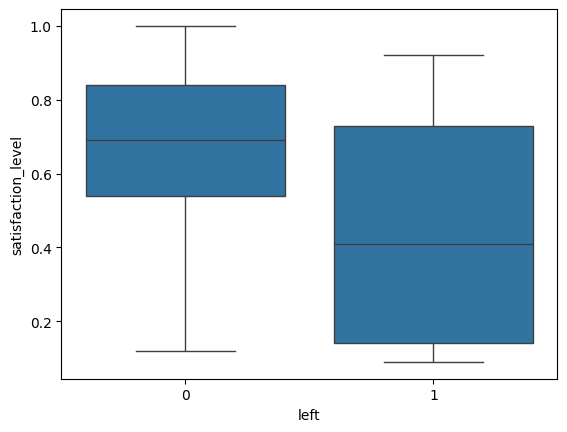

In [170]:
#box plot to show distributions with respect to categories
sns.boxplot(x="left", y= "satisfaction_level", data=df_merge_train)
#take-away: employee left most who has less satisfication level range from 0.2 to 0.5

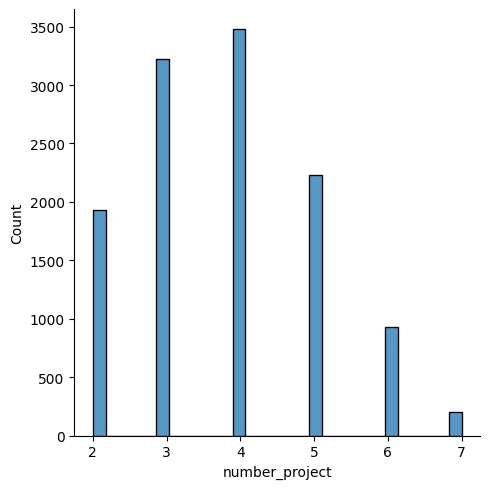

In [171]:
# number_project : plot a univariate distribution of observations
sns.displot(df_merge_train['number_project'])
#take-away: number_project distributed from 2 to 7 where it has high count at 4

<Axes: xlabel='left', ylabel='number_project'>

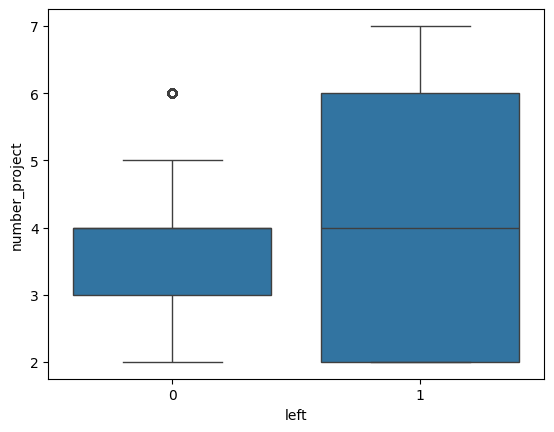

In [172]:
#box plot to show distributions with respect to categories
sns.boxplot(x="left", y= "number_project", data=df_merge_train)
#take-away: employee left when project count high.and employee retain who has number_project between 3-4

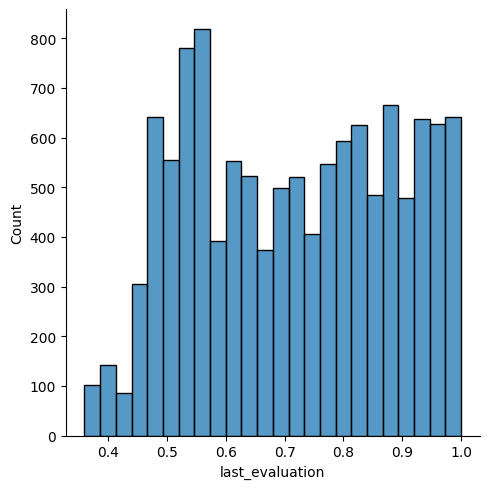

In [173]:
# last_evaluation : plot a univariate distribution of observations
sns.displot(df_merge_train['last_evaluation'])
#take-away: last_evaluation distributed from 0.35 to 1 where it has high count at around 0.55

<Axes: xlabel='left', ylabel='last_evaluation'>

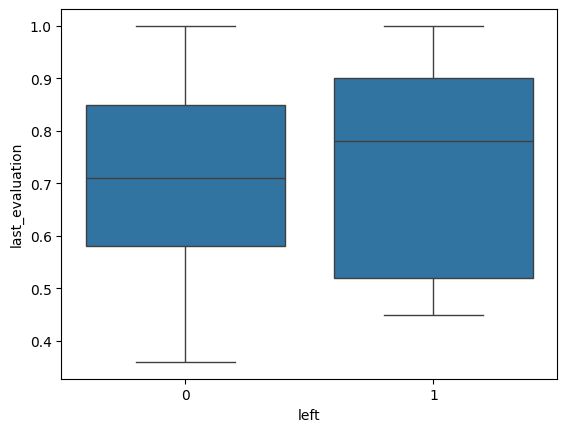

In [174]:
#box plot to show distributions with respect to categories
sns.boxplot(x="left", y= "last_evaluation", data=df_merge_train)
#take-away: not much impact but employee left who has high last_evaluation value

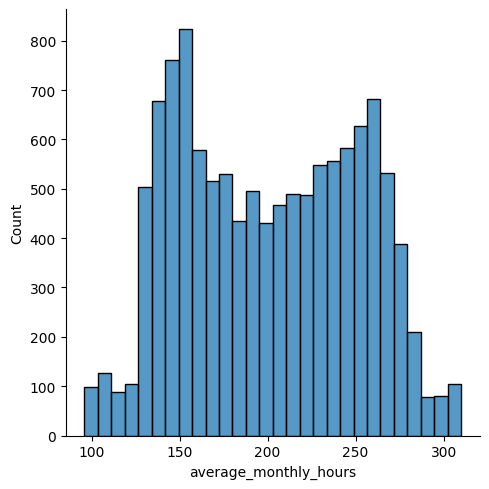

In [175]:
# average_monthly_hours : plot a univariate distribution of observations
sns.displot(df_merge_train['average_monthly_hours'])
#take-away: average_monthly_hours distributed from 100 to 300 where it has high count at around 150

<Axes: xlabel='left', ylabel='average_monthly_hours'>

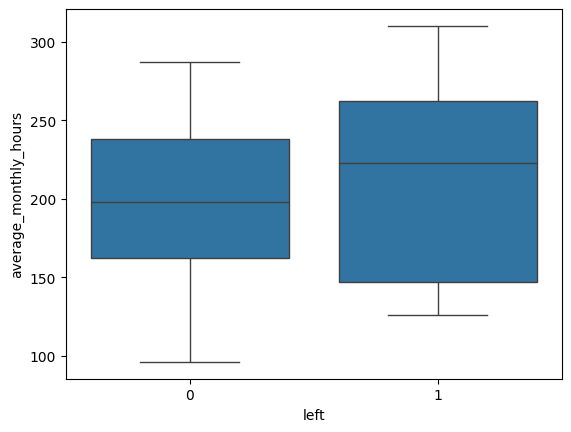

In [176]:
#box plot to show distributions with respect to categories
sns.boxplot(x="left", y= "average_monthly_hours", data=df_merge_train)
#take-away: employee left who has high average_monthly_hours value

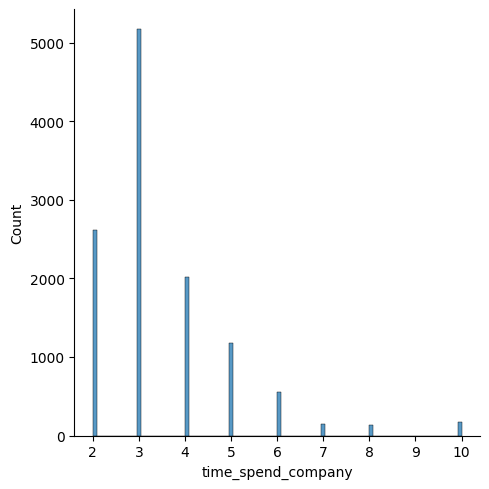

In [177]:
# time_spend_company : plot a univariate distribution of observations
sns.displot(df_merge_train['time_spend_company'])
#take-away: time_spend_company distributed from 2 to 10 where it has high count at around 3 and low at 9

<Axes: xlabel='left', ylabel='time_spend_company'>

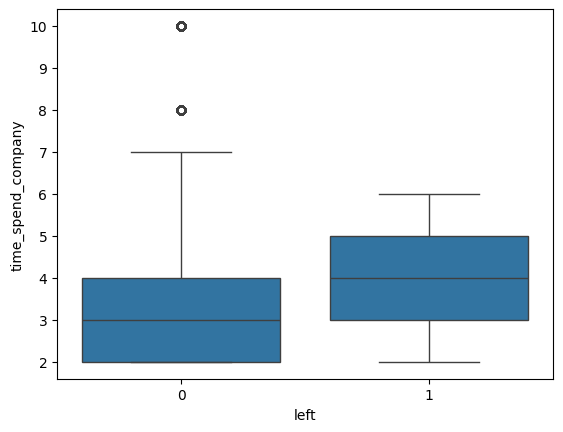

In [178]:
#box plot to show distributions with respect to categories
sns.boxplot(x="left", y= "time_spend_company", data=df_merge_train)
#take-away: employee left who has high time_spend_company value...

In [179]:
len(df_merge_train['salary'])

11999

In [213]:
df1_train = pd.get_dummies(df_merge_train,drop_first=True)
df1_test = pd.get_dummies(df_merge_test,drop_first=True)

<Axes: >

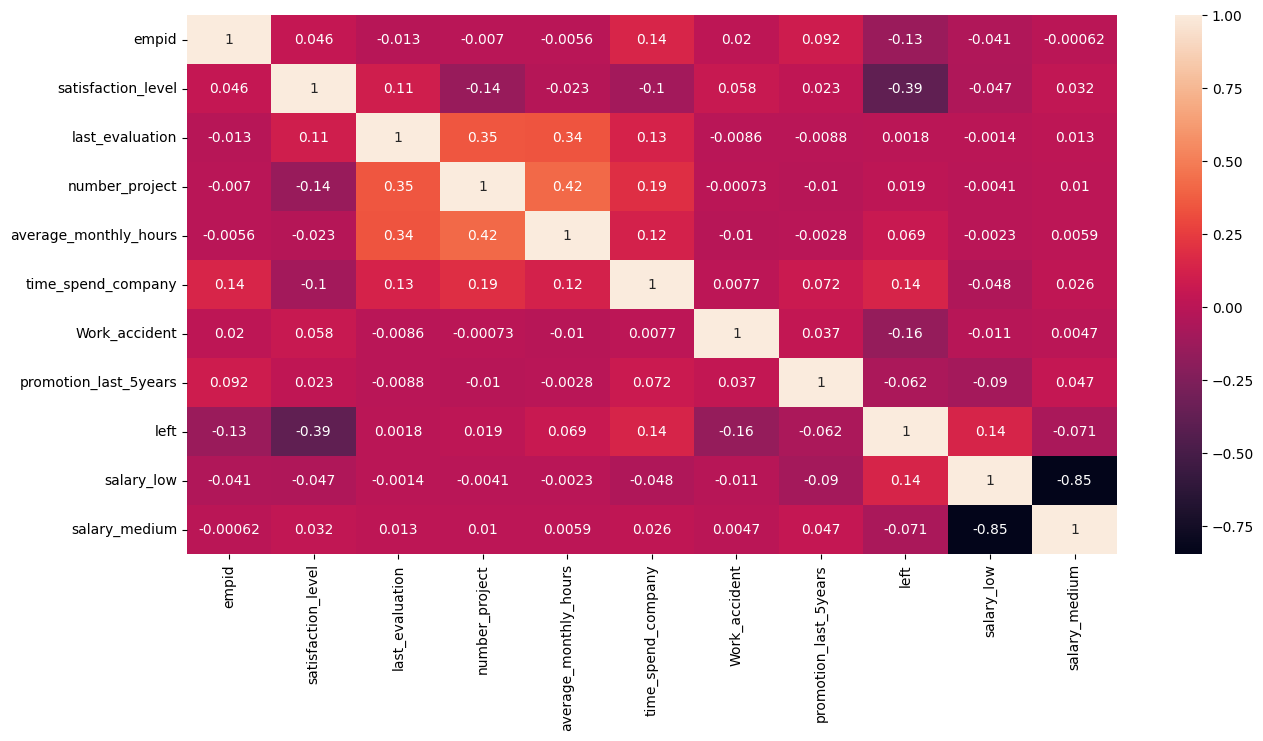

In [214]:
## Checking for correlation
cor_mat=df1_train.corr()
fig = plt.figure(figsize=(15,7))
sns.heatmap(cor_mat,annot=True)

In [215]:
df1_train.drop('salary_low',axis=1,inplace=True)
df1_test.drop('salary_low',axis=1,inplace=True)

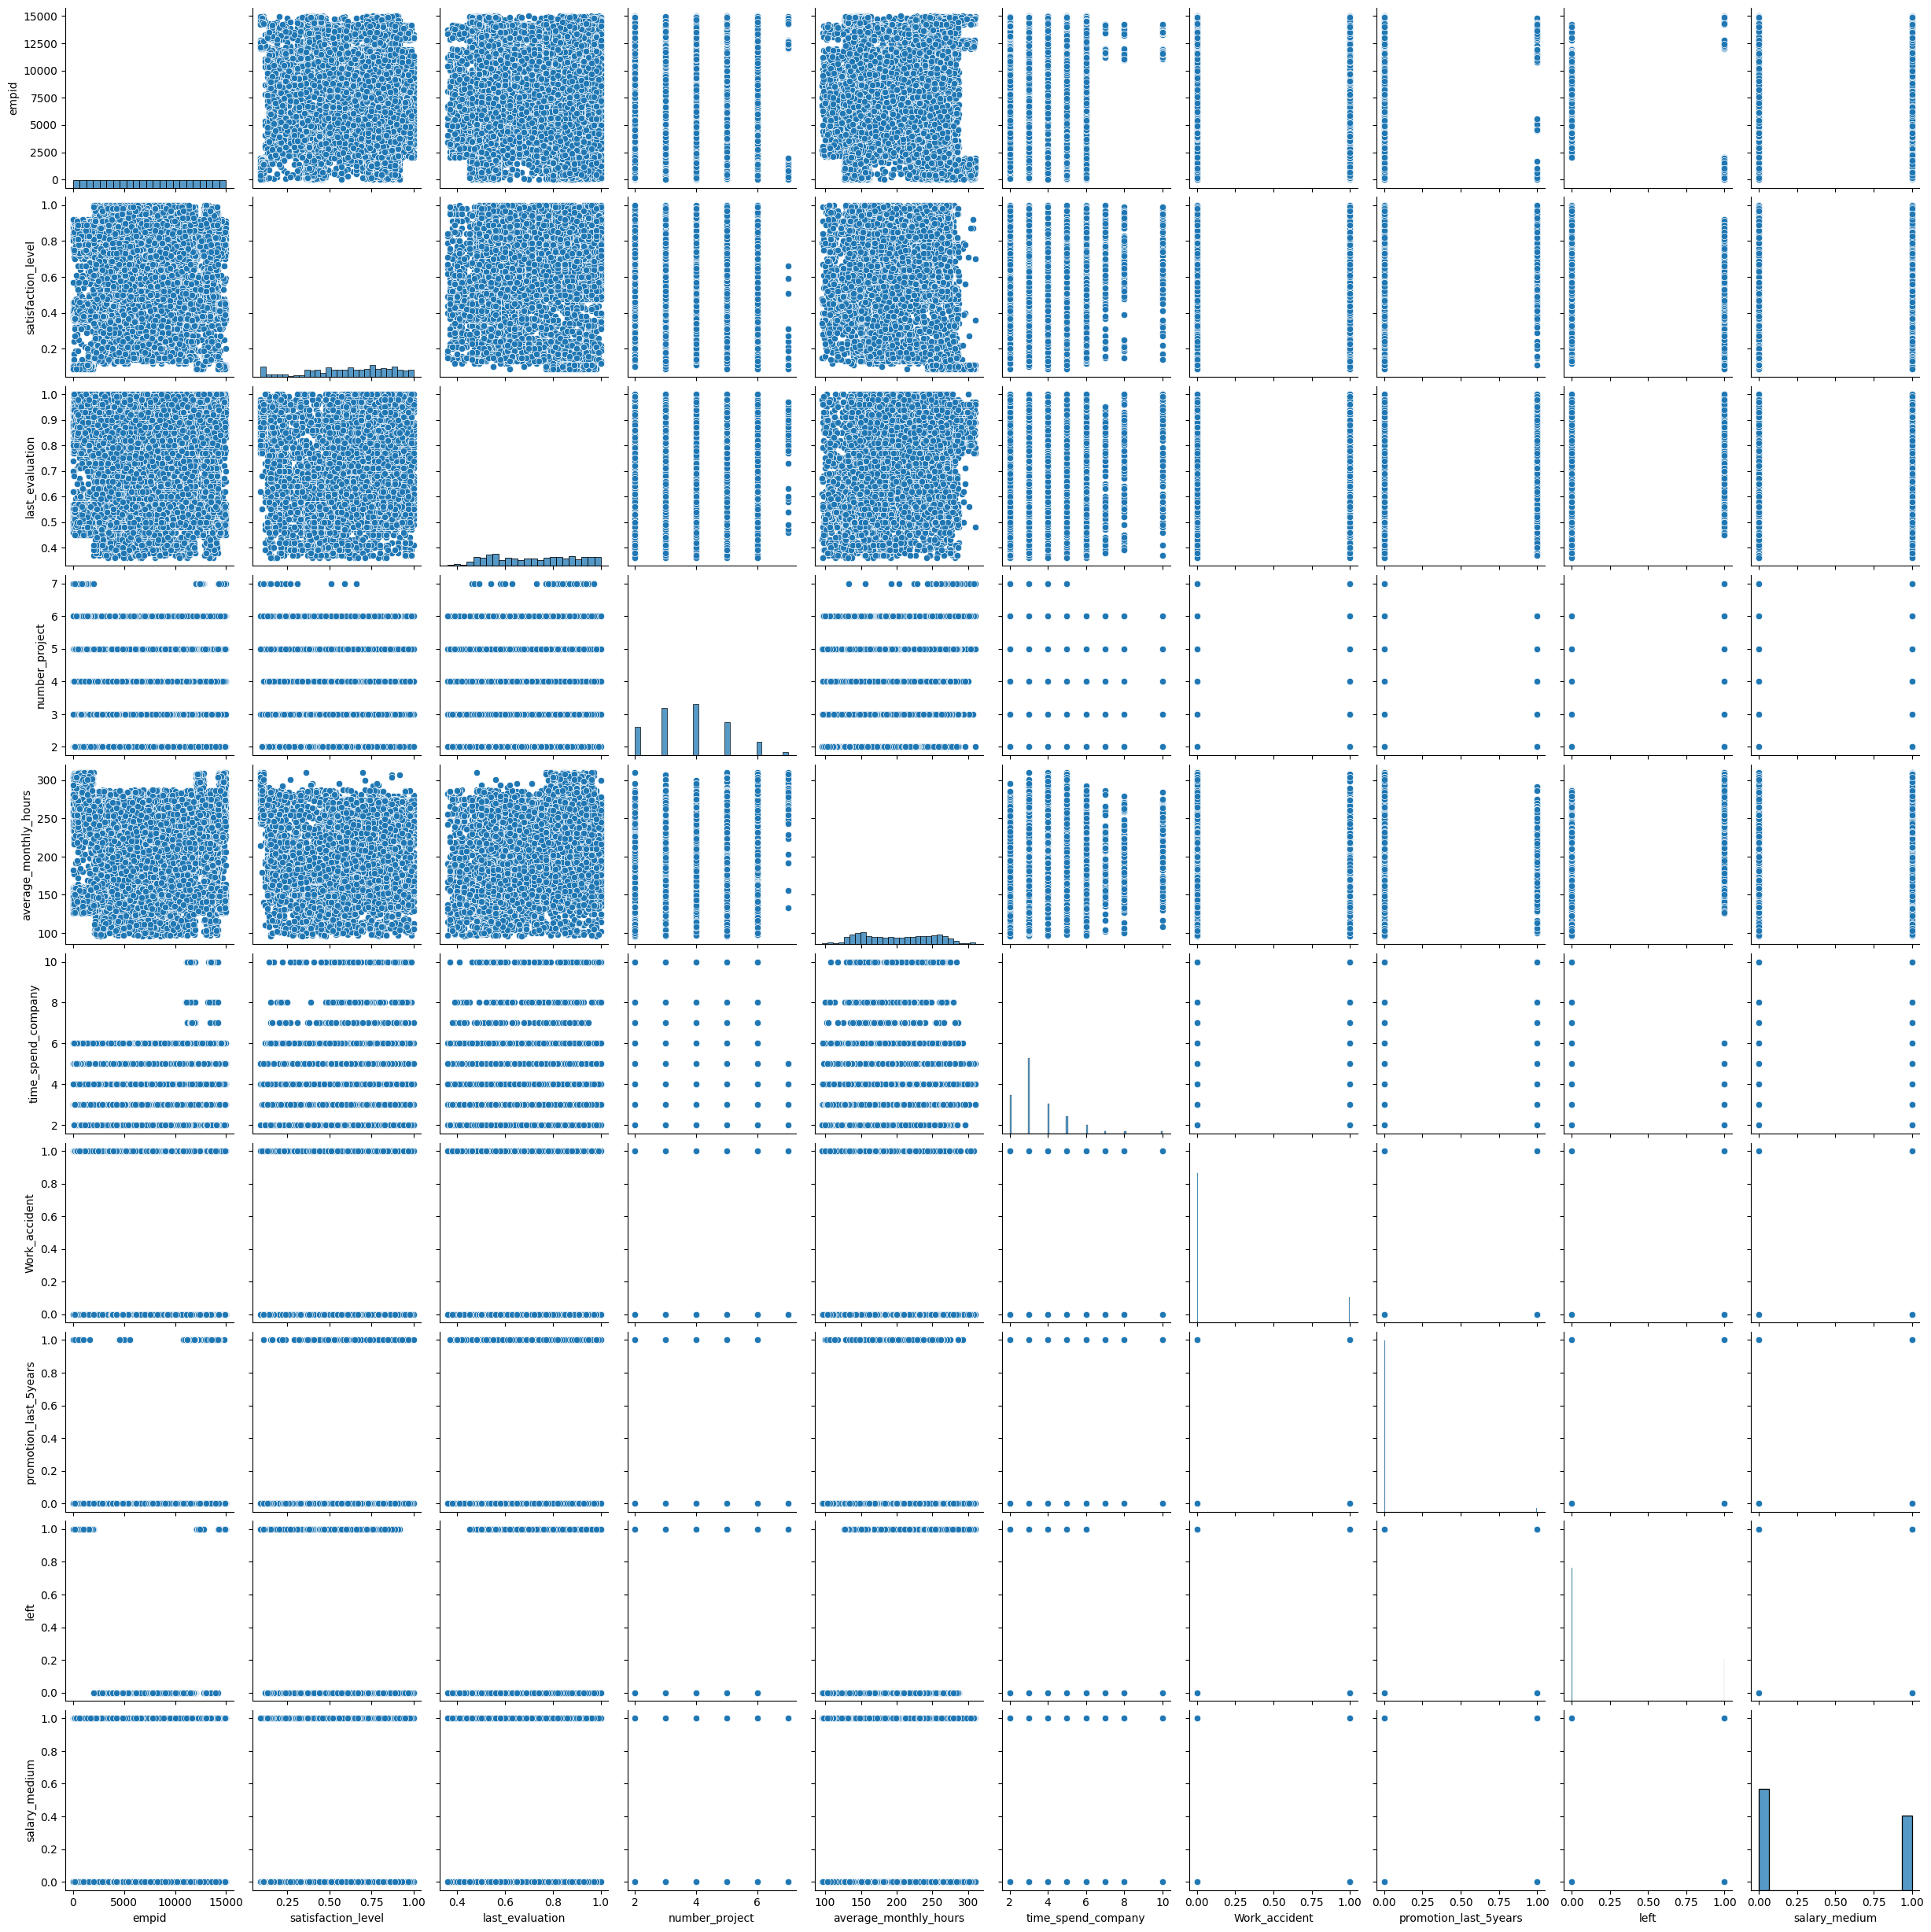

In [216]:
## Checking for pairplot
sns.pairplot(df1_train)

## Feature Engineering

In [217]:
df2_train = df1_train.copy()
df2_test = df1_test.copy()

In [218]:
df2_train.drop(['empid'],axis=1,inplace=True)
df2_test.drop(['empid'],axis=1,inplace=True)

In [219]:
df2_train.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,left,salary_medium
6026,0.49,0.46,2,129,2,0,0,0,False
11511,0.72,0.88,5,216,10,1,0,0,True
13663,0.82,0.51,2,268,2,0,0,0,False
11239,0.82,0.85,3,214,2,0,0,0,False
676,0.11,0.82,6,270,4,0,0,1,False


In [220]:
df2_train.isnull().sum()

satisfaction_level       1
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
left                     0
salary_medium            0
dtype: int64

In [221]:
df2_test.isna().sum()

satisfaction_level       1
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
left                     0
salary_medium            0
dtype: int64

In [222]:
df2_train['satisfaction_level'] = df2_train['satisfaction_level'].fillna(df2_train['satisfaction_level'].mean())
df2_test['satisfaction_level'] = df2_test['satisfaction_level'].fillna(df2_test['satisfaction_level'].mean())

In [223]:
df2_train.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
left                     0
salary_medium            0
dtype: int64

In [224]:
df2_test.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
left                     0
salary_medium            0
dtype: int64

## Split Dataset into Training set and Test set

In [225]:
#split dataset into features and label
X_train = df2_train.drop(labels='left',axis=1)
y_train = df2_train['left']

In [226]:
X_test = df2_test.drop(labels='left',axis=1)
y_test = df2_test['left']

In [228]:
len(X_train)

11999

In [229]:
len(X_test)

3000

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [233]:
X_train_scaled

array([[0.43956044, 0.15625   , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.69230769, 0.8125    , 0.6       , ..., 1.        , 0.        ,
        1.        ],
       [0.8021978 , 0.234375  , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.87912088, 0.453125  , 0.2       , ..., 0.        , 0.        ,
        0.        ],
       [0.52747253, 0.453125  , 0.4       , ..., 0.        , 0.        ,
        0.        ],
       [0.7032967 , 0.8125    , 0.6       , ..., 1.        , 0.        ,
        0.        ]], shape=(11999, 8))

In [234]:
X_test_scaled

array([[0.95604396, 0.890625  , 0.8       , ..., 0.        , 0.        ,
        0.        ],
       [0.57142857, 0.515625  , 0.2       , ..., 0.        , 0.        ,
        1.        ],
       [0.93406593, 0.390625  , 0.4       , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.95604396, 0.015625  , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.54945055, 0.671875  , 0.4       , ..., 0.        , 0.        ,
        1.        ],
       [0.9010989 , 0.296875  , 0.2       , ..., 0.        , 0.        ,
        0.        ]], shape=(3000, 8))

## Model Selection

In [ ]:
# Apply SMOTETomek to handle class imbalance
smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)

print(f"Original training set: {len(X_train)} samples (left=1: {sum(y_train==1)})")
print(f"After SMOTETomek:      {len(X_train_resampled)} samples (left=1: {sum(y_train_resampled==1)})")

Original training set: 11999 samples (left=1: 2857)
After SMOTETomek:      18222 samples (left=1: 9111)


In [236]:
model_param = {
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=42),
        'param': {
            'n_estimators': [50, 100, 150],
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 3, 5, 7],
            'max_features': ['sqrt', 'log2']
        }
    },
    'DecisionTreeClassifier': {
        'model': DecisionTreeClassifier(random_state=42),
        'param': {
            'criterion': ['gini', 'entropy'],
            'splitter': ['best', 'random'],
            'max_depth': [None, 3, 5, 7],
            'max_features': ['sqrt', 'log2']
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=10000, random_state=42),
        'param': {
            'C': [0.1, 0.5, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'LinearSVC': {
        'model': LinearSVC(max_iter=10000, random_state=42),
        'param': {
            'C': [0.1, 0.5, 1, 10],
            'loss': ['squared_hinge']
        }
    }
}

In [242]:
# GridSearchCV for all models on SMOTETomek resampled data
all_results = []

for model_name, mp in model_param.items():
    print(f"\nTraining {model_name}...")
    grid = GridSearchCV(
        estimator=mp['model'],
        param_grid=mp['param'],
        cv=5,
        scoring='f1',
        return_train_score=False,
        n_jobs=-1
    )
    grid.fit(X_train_resampled, y_train_resampled)

    y_pred = grid.best_estimator_.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)

    # AUC-ROC (use predict_proba if available, else decision_function)
    if hasattr(grid.best_estimator_, 'predict_proba'):
        y_proba = grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = grid.best_estimator_.decision_function(X_test_scaled)
    test_auc = roc_auc_score(y_test, y_proba)

    all_results.append({
        'model': model_name,
        'best_cv_f1': round(grid.best_score_, 4),
        'test_accuracy': round(test_acc, 4),
        'test_recall': round(test_recall, 4),
        'test_auc_roc': round(test_auc, 4),
        'best_params': grid.best_params_,
        'estimator': grid.best_estimator_
    })

    print(f"  CV F1={grid.best_score_:.4f}, Test Acc={test_acc:.4f}, Test Recall={test_recall:.4f}, AUC-ROC={test_auc:.4f}")
    print(f"  Best Params: {grid.best_params_}")


Training RandomForestClassifier...
  CV F1=0.9895, Test Acc=0.9913, Test Recall=0.9678, AUC-ROC=0.9948
  Best Params: {'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'n_estimators': 150}

Training DecisionTreeClassifier...
  CV F1=0.9790, Test Acc=0.9767, Test Recall=0.9664, AUC-ROC=0.9731
  Best Params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'splitter': 'best'}

Training LogisticRegression...
  CV F1=0.7763, Test Acc=0.7607, Test Recall=0.7969, AUC-ROC=0.8205
  Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}

Training LinearSVC...
  CV F1=0.7634, Test Acc=0.7540, Test Recall=0.7773, AUC-ROC=0.8185
  Best Params: {'C': 10, 'loss': 'squared_hinge'}


In [243]:
# Classification reports for all models
for result in all_results:
    y_pred = result['estimator'].predict(X_test_scaled)
    print(f"\n{'='*60}")
    print(f"Classification Report - {result['model']}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred))


Classification Report - RandomForestClassifier
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       1.00      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000


Classification Report - DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2286
           1       0.94      0.97      0.95       714

    accuracy                           0.98      3000
   macro avg       0.96      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000


Classification Report - LogisticRegression
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      2286
           1       0.50      0.80      0.61       714

    accuracy                           0.7

In [244]:
# Summary table
summary_df = pd.DataFrame([
    {
        'Model': r['model'],
        'CV F1 Score': r['best_cv_f1'],
        'Test Accuracy': r['test_accuracy'],
        'Test Recall': r['test_recall'],
        'AUC-ROC': r['test_auc_roc'],
        'Best Params': str(r['best_params'])
    }
    for r in all_results
])

print("SUMMARY: All Models with SMOTETomek")
print("=" * 60)
print(summary_df.to_string(index=False))

# Select best model based on CV F1
best_result = max(all_results, key=lambda x: x['best_cv_f1'])
print(f"\nBEST MODEL: {best_result['model']}")
print(f"  CV F1: {best_result['best_cv_f1']}")
print(f"  Test Accuracy: {best_result['test_accuracy']}")
print(f"  Test Recall: {best_result['test_recall']}")
print(f"  AUC-ROC: {best_result['test_auc_roc']}")
print(f"  Params: {best_result['best_params']}")

SUMMARY: All Models with SMOTETomek
                 Model  CV F1 Score  Test Accuracy  Test Recall  AUC-ROC                                                                             Best Params
RandomForestClassifier       0.9895         0.9913       0.9678   0.9948   {'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'n_estimators': 150}
DecisionTreeClassifier       0.9790         0.9767       0.9664   0.9731 {'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'splitter': 'best'}
    LogisticRegression       0.7763         0.7607       0.7969   0.8205                                       {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
             LinearSVC       0.7634         0.7540       0.7773   0.8185                                                      {'C': 10, 'loss': 'squared_hinge'}

BEST MODEL: RandomForestClassifier
  CV F1: 0.9895
  Test Accuracy: 0.9913
  Test Recall: 0.9678
  AUC-ROC: 0.9948
  Params: {'criterion': 'gini', 'max_depth'

In [240]:
# Save the best model and scaler as pkl files
os.makedirs('models', exist_ok=True)

joblib.dump(best_result['estimator'], 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print(f"Saved best model: {best_result['model']} -> models/best_model.pkl")
print(f"Saved scaler -> models/scaler.pkl")

# Verify
print("\nAll saved models:")
for f in os.listdir('models'):
    print(f"  {f}")

Saved best model: DecisionTreeClassifier -> models/best_model.pkl
Saved scaler -> models/scaler.pkl

All saved models:
  best_model.pkl
  scaler.pkl
